![Ecommerce Sales Cover](ecommerce_sales_cover.png)

# Sales Forecasting and Market-Basket Analysis for a Kenyan Baby Products Retailer

This project predicts future sales and uncovers which products are bought together, using 36 months of data from a Kenyan baby-products retailer. The results help the business plan stock and design bundles that increase order value.

### 1.Business Understanding

### 1.1 Background

The client is a Kenyan retailer of baby products that sells through three channels: a physical point of sale, an online store and draft orders. The dataset covers 36 months of trading, from November 2020 to October 2023, and contains 28,755 transaction lines recorded in Kenyan shillings (KES). Over this period the business grew quickly, with yearly order counts rising from about 3,000 in 2021 to over 5,700 in the first ten months of 2023, and monthly net sales climbing from under KES 1 million to a peak of roughly KES 4.4 million.

This growth makes planning harder. Stock, cash and promotions are still decided largely from experience, so the retailer risks running out of fast-moving items such as formula and diapers, or tying up money in slow-moving ones. The retailer also does not know which products customers tend to buy together, even though about two in three orders contain more than one distinct product.

### 1.2 Problem Statement

The retailer plans stock, cash and promotions mostly from experience, without a forecast of future demand and without knowing which products customers buy together. This leads to two costly problems: popular items such as formula and diapers can run out while slow-moving items tie up money, and chances to raise order value through bundles and add-on offers are missed.

> **How can past transaction data be used to forecast monthly sales and to identify the products customers frequently buy together?**

### 1.3 Business Objectives

1. **Plan stock and cash better.** Know roughly how much the business will sell in the coming months, so it can order the right quantities and avoid stock-outs and overstocking.
2. **Increase the value of each order.** Find products that are often bought together, so the retailer can offer bundles, place related items near each other and suggest add-ons.
3. **Make the results easy to use.** Give the owner outputs that can be read and applied without technical knowledge.

### 1.4 Data Science Objectives

Each business objective is turned into a specific analysis task.

| Business objective | Data science task | Method |
|---|---|---|
| Plan stock and cash better | Forecast monthly net sales (total, then by product category) for the next 3 months | Time-series forecasting, starting from a seasonal-naive baseline |
| Increase the value of each order | Find product and category combinations that appear together in orders more often than chance | Market-basket analysis (association rules with Apriori or FP-Growth) |
| Make the results easy to use | Save the final model and rules and provide a simple function and report | Model persistence and a lightweight app |

### 1.5 Success Criteria (Metrics of Success)

These targets are set before modeling, so the results are judged fairly in the Evaluation phase.

**Sales forecasting**
- **Primary metric:** WAPE (weighted absolute percentage error), measured on the last 3 months held out from training.
- **Target:** WAPE of 15% or lower for total monthly sales.
- **Baseline to beat:** a seasonal-naive forecast. The chosen model should improve on it by at least 10%.

**Market-basket analysis**
- **Support** of at least 0.5% of orders, so rules are not based on a handful of orders.
- **Confidence** of at least 20% and **lift** of at least 1.2, meaning the products sell together at least 20% more often than chance.
- **Usefulness:** at least 10 rules that the retailer considers worth acting on.

These thresholds are starting points and may be adjusted once we see how sparse the baskets are.

### 1.6 Scope and Assumptions

**In scope**
- Monthly sales forecasting for total net sales and by product category.
- Market-basket analysis at order level, using products and categories.
- Transactions from November 2020 to October 2023, in Kenyan shillings (KES).

**Out of scope**
- Customer-level analysis, because the data has no customer ID.
- Daily forecasts for individual products, because the data is too sparse.
- Pricing optimization.

**Assumptions**
- One order (`order_name`) represents one shopping basket.
- Net sales is the revenue measure to forecast.
- Delivery charges, gift cards and other non-product lines are not products and will be excluded from the basket analysis.

### 1.7 Risks and Constraints

| Risk | Why it matters | How we will handle it |
|---|---|---|
| Only 36 months of history | Seasonality is hard to estimate from three yearly cycles | Use simple, robust models and report forecast uncertainty |
| Strong growth over the period | Models that ignore trend will underpredict | Use methods that handle trend, such as Holt-Winters or SARIMA |
| Delivery "Rider" charges recorded as products | They would create meaningless product pairings | Identify and remove them in Data Preparation |
| Inconsistent product names and many missing categories | Pairs get split across spellings and rules weaken | Standardize names and build a product-to-category mapping |
| Timestamps stored in UTC | Late-evening orders could fall into the wrong month | Convert to Nairobi time (UTC+3) before grouping |
| No customer ID | Customers cannot be segmented | Analyse at order level only |

### 1.8 Project Plan

| Phase | Main work | Output |
|---|---|---|
| 2. Data Understanding | Load data, explore it, check quality | Data profile and EDA findings |
| 3. Data Preparation | Clean products, convert time zone, build monthly series and basket table | Analysis-ready datasets |
| 4. Modeling | Baseline first, then tuned forecasting models and association rules | Trained models and rules |
| 5. Evaluation | Compare results with the success criteria in 1.5 | Pass or fail assessment and recommendations |
| 6. Deployment | Save the model, build a reusable pipeline and a simple app | Working tool for the retailer |

## 2. Data Understanding

### 2.1 Data Collection

The sales data comes from the `sales` table in PostgreSQL. It was loaded from the retailer's Excel export, which lists one row per sale line (an order can have several lines). The same table exists in a local PostgreSQL database and in a Neon cloud copy, so a single loader below can read either one by changing the `SOURCE` setting. After loading, the shape of the data is checked against the expected 28,755 rows and 17 columns, so a failed or partial load is caught immediately.

In [30]:
# core libraries and notebook display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [31]:
def get_engine(source: str = "local"):
    """Create a SQLAlchemy engine for the local or the Neon PostgreSQL database.

    Credentials are read from the .env file, never hard-coded.
    """
    load_dotenv(override=True)
    if source == "local":
        url = (
            f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
            f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
            "?sslmode=prefer"   # local Postgres has no SSL; use it only if available
        )
    elif source == "neon":
        url = os.getenv("NEON_URL").replace("postgresql://", "postgresql+psycopg2://", 1)
    else:
        raise ValueError("source must be 'local' or 'neon'")
    return create_engine(url)


SOURCE = "neon"                      # change to "neon" to read the cloud copy
EXPECTED_SHAPE = (28755, 17)

engine = get_engine(SOURCE)
df = pd.read_sql("SELECT * FROM sales", con=engine)

print(f"Source: {SOURCE} | shape: {df.shape}")
assert df.shape == EXPECTED_SHAPE, f"Unexpected shape {df.shape}, expected {EXPECTED_SHAPE}"
print("Load check passed.")

Source: neon | shape: (28755, 17)
Load check passed.


### 2.2 Initial Data Exploration

Before any charts, the structure and quality of the table are checked: column types, a first look at the rows, missing values, duplicates and basic consistency of the money columns. The aim is to find problems early so that they can be handled in Data Preparation.

In [32]:

# First and last rows (the table is in date order, so the tail shows the latest sales)
display(df.head(3))


,sale_id,order_id,date,order_name,transaction_type,sale_type,sales_channel,product_type,product,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
0,8725409595544,2854884835480,2020-11-10 22:39:33+00:00,TS1011,product,order,Online Store,Bathing & Skin Care,Mamia Sensitive Bathing & Skin Care 64 Bathing...,1,200.0,0.0,0.0,200.0,0.0,0.0,200.0
1,8752046604440,2864488448152,2020-11-16 13:43:01+00:00,TS1012,product,order,Point of Sale,Baby Formula,NANNYcare Growing Up Milk Goat Milk Based 3 Fr...,2,9000.0,0.0,0.0,9000.0,0.0,0.0,9000.0
2,8752055845016,2864491954328,2020-11-16 13:45:58+00:00,TS1013,product,order,Point of Sale,Baby Diapers,DryNites Spider-Man Baby & Toddler Clothing 16pk,1,1800.0,0.0,0.0,1800.0,0.0,0.0,1800.0


In [33]:
# Structure: columns, types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28755 entries, 0 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   sale_id           28755 non-null  int64              
 1   order_id          28755 non-null  int64              
 2   date              28755 non-null  datetime64[us, UTC]
 3   order_name        28755 non-null  str                
 4   transaction_type  28755 non-null  str                
 5   sale_type         28755 non-null  str                
 6   sales_channel     28755 non-null  str                
 7   product_type      17244 non-null  str                
 8   product           27845 non-null  str                
 9   net_quantity      28755 non-null  int64              
 10  gross_sales       28755 non-null  float64            
 11  discounts         28755 non-null  float64            
 12  returns           28755 non-null  float64            
 13  net_sales   

In [34]:
# Numeric columns: scale, spread and extreme values
display(df.describe().T.round(2))

# Text columns: how many distinct values and the most common one
display(df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
sale_id,28755.0,1.502482e+13,2.100030e+12,8.725410e+12,1.472930e+13,1.584411e+13,1.648706e+13,1.708426e+13
order_id,28755.0,4.725462e+12,6.424951e+11,2.854885e+12,4.601180e+12,4.953558e+12,5.182479e+12,5.390480e+12
net_quantity,28755.0,1.350000e+00,1.330000e+00,-1.200000e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.600000e+01
gross_sales,28755.0,2.901050e+03,4.470600e+03,0.000000e+00,4.200000e+02,1.500000e+03,3.300000e+03,1.020000e+05
discounts,28755.0,-8.050000e+00,1.790600e+02,-1.620000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
returns,28755.0,-2.398000e+01,4.870700e+02,-3.840000e+04,0.000000e+00,0.000000e+00,0.000000e+00,8.500000e+03
net_sales,28755.0,2.869020e+03,4.486250e+03,-3.840000e+04,4.200000e+02,1.500000e+03,3.300000e+03,1.020000e+05
shipping,28755.0,9.870000e+00,7.172000e+01,-8.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+02
taxes,28755.0,3.300000e-01,1.529000e+01,-1.120000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+03
total_sales,28755.0,2.879230e+03,4.480650e+03,-3.840000e+04,4.500000e+02,1.500000e+03,3.300000e+03,1.020000e+05


C:\Users\user\AppData\Local\Temp\ipykernel_15388\848020311.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
order_name,28755,13257,TS5441,24
transaction_type,28755,4,product,27843
sale_type,28755,2,order,28438
sales_channel,28755,3,Point of Sale,25696
product_type,17244,100,Baby Formula,5727
product,27845,1923,Rider,1062


In [35]:
# Missing values per column
missing = (
    df.isna().sum().to_frame("missing")
      .assign(pct=lambda t: (t["missing"] / len(df) * 100).round(1))
      .query("missing > 0")
      .sort_values("missing", ascending=False)
)
display(missing)

# Duplicates: sale_id should be unique; also check fully identical rows
print("Duplicate sale_id values :", df["sale_id"].duplicated().sum())
print("Fully duplicated rows    :", df.duplicated().sum())

,missing,pct
product_type,11511,40.0
product,910,3.2


Duplicate sale_id values : 0
Fully duplicated rows    : 0


In [36]:
# Time coverage (the timestamps are stored in UTC)
print("Date range:", df["date"].min(), "->", df["date"].max())

# Distribution of the key categorical columns
for col in ["transaction_type", "sale_type", "sales_channel"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).to_string())

# Product type labels: stray spaces would split one category into two
print("\nUnique product_type labels:", df["product_type"].nunique())
print("After trimming spaces     :", df["product_type"].str.strip().nunique())
print("Unique product names      :", df["product"].nunique())

Date range: 2020-11-10 22:39:33+00:00 -> 2023-10-31 15:26:21+00:00

transaction_type
transaction_type
product      27843
shipping       893
unknown         17
gift_card        2

sale_type
sale_type
order     28438
return      317

sales_channel
sales_channel
Point of Sale    25696
Online Store      3054
Draft Orders         5

Unique product_type labels: 100
After trimming spaces     : 98
Unique product names      : 1923


In [37]:
# Integrity check: total_sales should equal net_sales + shipping + taxes
calc_total = df["net_sales"] + df["shipping"] + df["taxes"]
mismatch = (calc_total - df["total_sales"]).abs() > 0.01
print("Rows where total_sales does not reconcile:", mismatch.sum())

# Integrity check: net_sales should equal gross_sales - discounts - returns, with signs as stored
alt_net = df["gross_sales"] + df["discounts"] + df["returns"]
print("Rows where net_sales does not reconcile  :", ((alt_net - df["net_sales"]).abs() > 0.01).sum())

Rows where total_sales does not reconcile: 0
Rows where net_sales does not reconcile  : 0


### 2.3 Exploratory Data Analysis (EDA)

This section looks for patterns, relationships, outliers and distributions that will shape data preparation and modeling. Nothing is removed from the data here. Working copies are created for analysis only, and all cleaning decisions are made in Phase 3.

In [38]:
# Working copy for EDA. The original df stays untouched.
eda = df.copy()

# Timestamps are stored in UTC; the business trades in Nairobi time (UTC+3),
# so convert before extracting month, weekday or hour.
eda["date_local"] = pd.to_datetime(eda["date"], utc=True).dt.tz_convert("Africa/Nairobi")
local_naive = eda["date_local"].dt.tz_localize(None)       # drop tz, keep local clock time
eda["month"]     = local_naive.dt.to_period("M")
eda["year"]      = local_naive.dt.year
eda["month_num"] = local_naive.dt.month
eda["weekday"]   = local_naive.dt.day_name()
eda["hour"]      = local_naive.dt.hour

# Product order lines only (no shipping, gift cards, unknown lines or returns)
prod = eda[(eda["transaction_type"] == "product") & (eda["sale_type"] == "order")].copy()

# Flag delivery-rider charges that were recorded as products
prod["is_rider"] = prod["product"].str.contains(r"\brider\b", case=False, na=False)
items = prod[~prod["is_rider"]].copy()                      # genuine product lines

print(f"All lines: {len(eda):,} | product order lines: {len(prod):,} | "
      f"rider lines: {prod['is_rider'].sum():,} | genuine product lines: {len(items):,}")

All lines: 28,755 | product order lines: 27,608 | rider lines: 4,618 | genuine product lines: 22,990


#### Sales trend over time

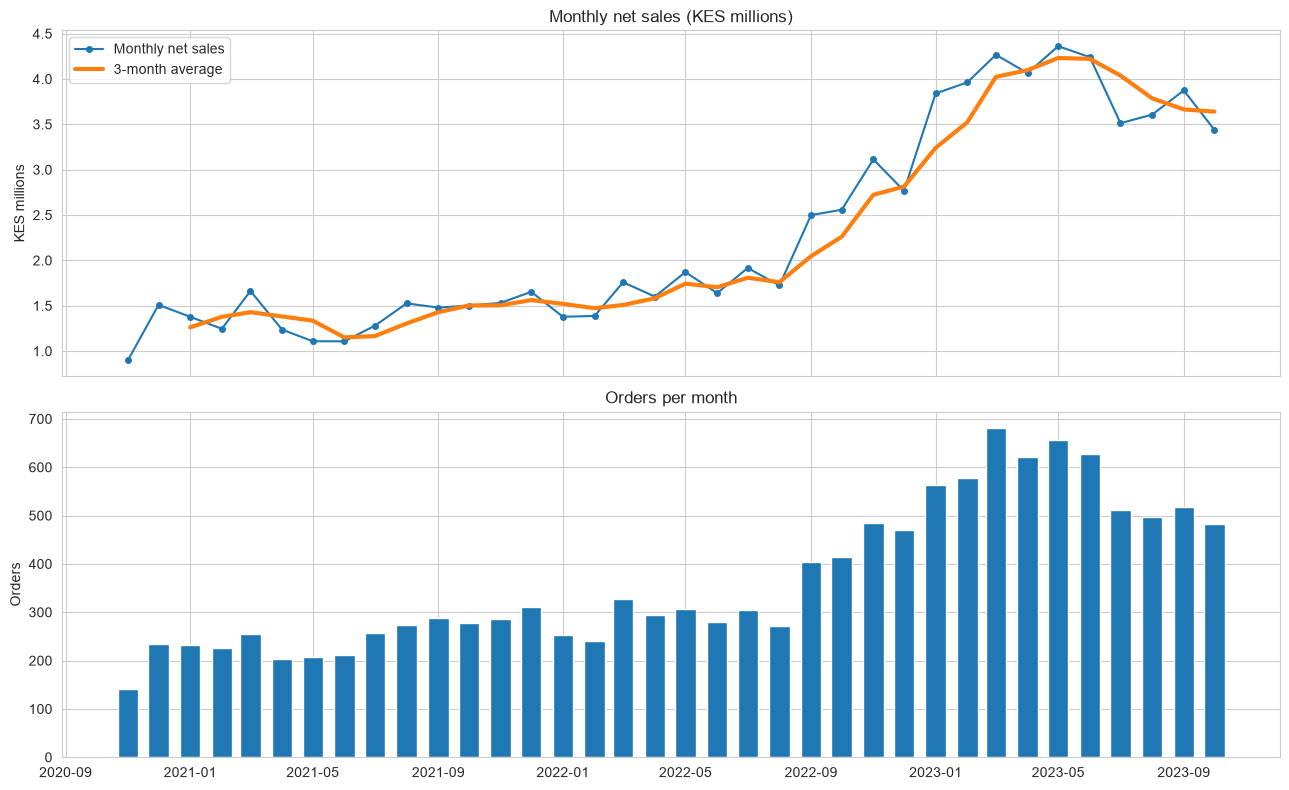

,net_sales_m,orders,sales_3m_avg
month,,,
2020-11-01,0.90,142,NaN
2020-12-01,1.51,235,NaN
2021-01-01,1.38,232,1.26


,net_sales_m,orders,sales_3m_avg
month,,,
2023-08-01,3.61,497,3.79
2023-09-01,3.87,518,3.66
2023-10-01,3.44,482,3.64


In [39]:
# Monthly net sales (all lines) and number of product orders
monthly = pd.DataFrame({
    "net_sales_m": eda.groupby("month")["net_sales"].sum() / 1e6,        # KES millions
    "orders":      items.groupby("month")["order_name"].nunique(),
}).fillna(0)
monthly["sales_3m_avg"] = monthly["net_sales_m"].rolling(3).mean()
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(monthly.index, monthly["net_sales_m"], marker="o", ms=4, label="Monthly net sales")
axes[0].plot(monthly.index, monthly["sales_3m_avg"], lw=3, label="3-month average")
axes[0].set(title="Monthly net sales (KES millions)", ylabel="KES millions")
axes[0].legend()

axes[1].bar(monthly.index, monthly["orders"], width=20)
axes[1].set(title="Orders per month", ylabel="Orders")
plt.tight_layout()
plt.show()

display(monthly.round(2).head(3)); display(monthly.round(2).tail(3))

#### Yearly pattern (seasonality)

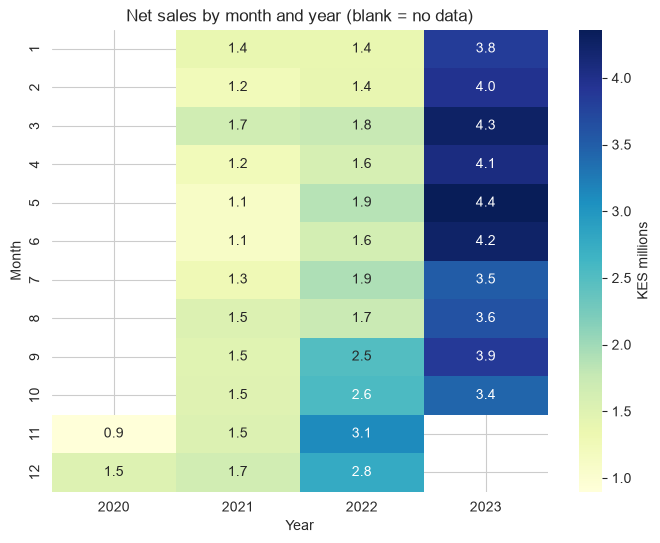

,Jan-Oct net sales (KES m),yoy_growth_pct
year,,
2021,13.5,NaN
2022,18.3,35.6
2023,39.2,114.2


In [40]:
# Net sales by calendar month and year (KES millions)
heat = eda.pivot_table(index="month_num", columns="year", values="net_sales", aggfunc="sum") / 1e6

plt.figure(figsize=(8, 6))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "KES millions"})
plt.title("Net sales by month and year (blank = no data)")
plt.ylabel("Month"); plt.xlabel("Year")
plt.show()

# Growth on a like-for-like basis: January to October of each full year
jan_oct = (eda[eda["month_num"] <= 10].groupby("year")["net_sales"].sum() / 1e6).round(1)
display(jan_oct.to_frame("Jan-Oct net sales (KES m)").assign(
    yoy_growth_pct=lambda t: (t.iloc[:, 0].pct_change() * 100).round(1)))

#### Channels and categories

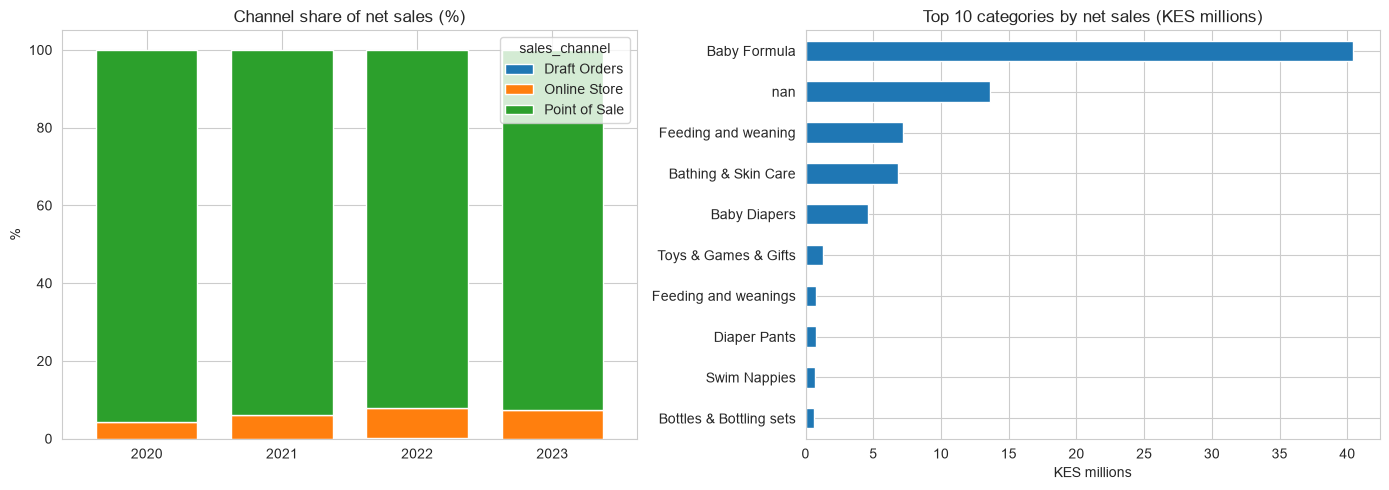

Product lines without a category: 5,936 (25.8%), carrying 16.6% of product net sales


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Channel share of net sales by year
ch = eda.pivot_table(index="year", columns="sales_channel", values="net_sales", aggfunc="sum")
(ch.div(ch.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, ax=axes[0], width=0.75)
axes[0].set(title="Channel share of net sales (%)", ylabel="%", xlabel="")
axes[0].tick_params(axis="x", rotation=0)

# Top product categories (labels trimmed so " Baby Diapers" and "Baby Diapers" merge)
cat = (items.assign(product_type=items["product_type"].str.strip())
            .groupby("product_type", dropna=False)["net_sales"].sum().sort_values(ascending=False))
(cat.head(10) / 1e6).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set(title="Top 10 categories by net sales (KES millions)", xlabel="KES millions", ylabel="")
plt.tight_layout(); plt.show()

# How much revenue has no category at all?
missing_cat = items["product_type"].isna()
print(f"Product lines without a category: {missing_cat.sum():,} "
      f"({missing_cat.mean():.1%}), carrying {items.loc[missing_cat, 'net_sales'].sum() / items['net_sales'].sum():.1%} of product net sales")

#### Products and the "Rider" check

In [42]:
# Most frequently sold names in product lines, before removing riders
top = (prod.groupby("product")
           .agg(lines=("sale_id", "count"), net_sales=("net_sales", "sum"), is_rider=("is_rider", "max"))
           .sort_values("lines", ascending=False).head(15))
display(top)

rider = prod[prod["is_rider"]]
print(f"\nRider lines: {len(rider):,} | names: {sorted(rider['product'].unique())[:10]}")
print(f"Rider net sales: KES {rider['net_sales'].sum():,.0f} "
      f"({rider['net_sales'].sum() / prod['net_sales'].sum():.1%} of product-line sales)")

# How fragmented are the product names?
print(f"\nUnique product names: {items['product'].nunique():,}")
print(f"Names sold only once: {(items['product'].value_counts() == 1).sum():,}")

,lines,net_sales,is_rider
product,,,
Rider,1061,276907.31,True
Rider Rajab,848,223450.00,True
Rider Peter,790,221830.00,True
Aptamil Stage 2 Follow On Milk Powder 800g,710,3951300.00,False
Aptamil 2 Follow On Milk Powder 800G,611,4046500.00,False
Aptamil 1 First Baby Milk Formula from Birth 800g,562,3453076.52,False
Rajab,527,143690.00,False
Aptamil Stage 1 First Infant Milk Powder from Birth 800g,465,2808600.00,False
Peter,432,121070.00,False



Rider lines: 4,618 | names: ['Amos rider', 'Delivery (Rider Jeff )', 'Geofrey rider', 'Januari Bolt Rider', 'Jeff rider', 'Michael  rider', 'Rahab rider', 'Rajab Rider', 'Rajab rider', 'Rider']
Rider net sales: KES 1,228,413 (1.5% of product-line sales)

Unique product names: 1,836
Names sold only once: 525


#### Orders and baskets

Orders: 13,191
Orders with 2+ distinct products: 42.5%


,n_products,units,order_value
count,13191.0,13191.0,13191.0
mean,1.7,2.6,6213.3
std,1.2,2.6,6890.5
min,1.0,1.0,120.0
50%,1.0,2.0,4200.0
90%,3.0,5.0,12600.0
99%,6.0,12.0,30400.0
max,23.0,60.0,192000.0


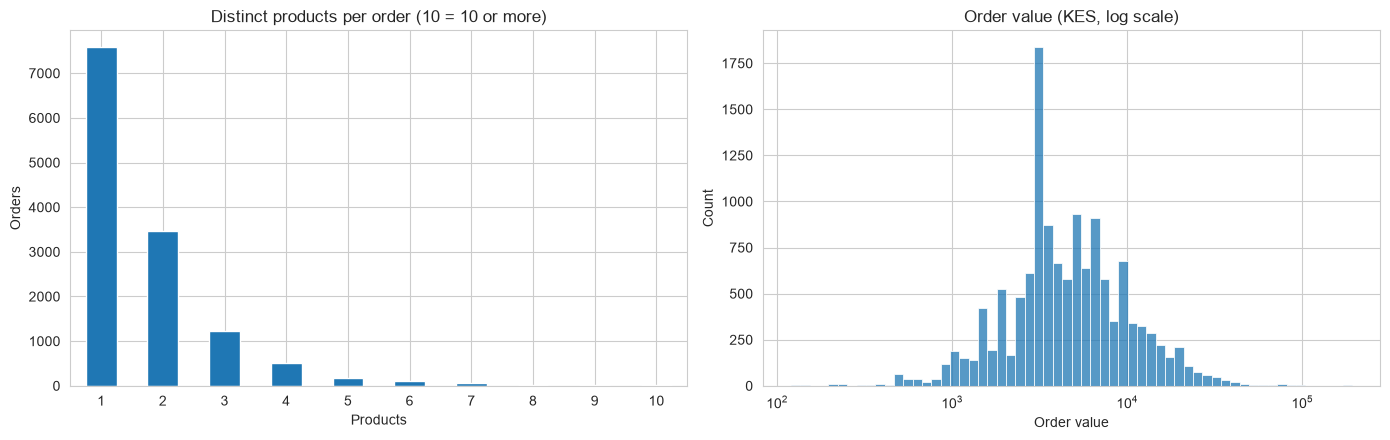

In [43]:
# One row per order (genuine products only)
orders = (items.groupby("order_name")
               .agg(n_products=("product", "nunique"),
                    units=("net_quantity", "sum"),
                    order_value=("net_sales", "sum"),
                    first_seen=("date_local", "min")))

print(f"Orders: {len(orders):,}")
print(f"Orders with 2+ distinct products: {(orders['n_products'] >= 2).mean():.1%}")
display(orders[["n_products", "units", "order_value"]].describe(percentiles=[.5, .9, .99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
orders["n_products"].clip(upper=10).value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set(title="Distinct products per order (10 = 10 or more)", xlabel="Products", ylabel="Orders")
axes[0].tick_params(axis="x", rotation=0)

sns.histplot(orders["order_value"], bins=60, log_scale=True, ax=axes[1])
axes[1].set(title="Order value (KES, log scale)", xlabel="Order value")
plt.tight_layout(); plt.show()

#### Outliers and distributions

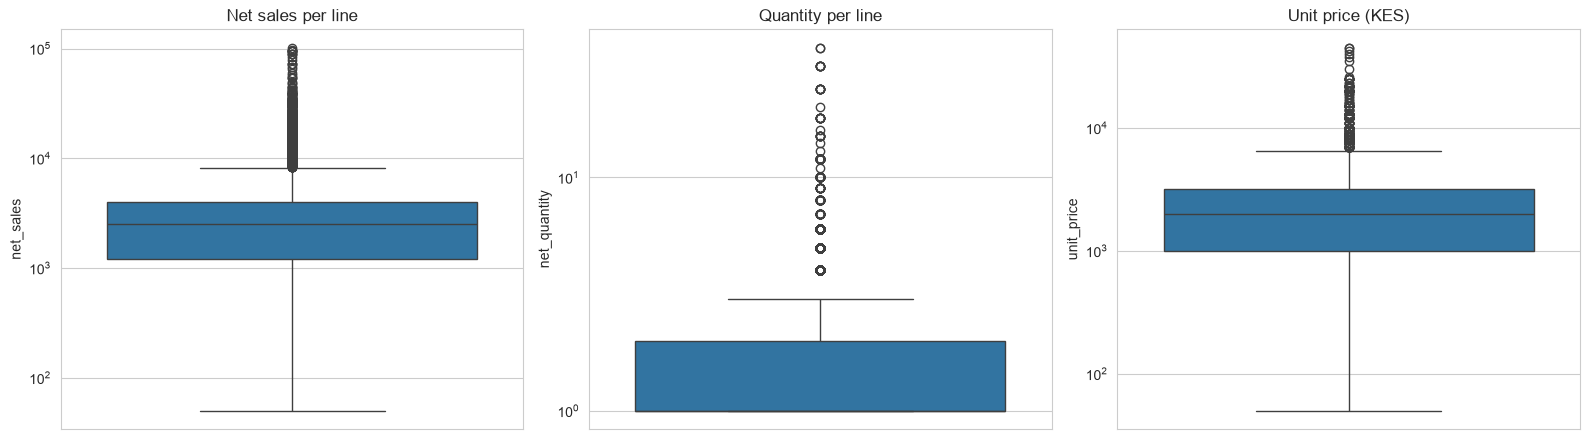

Lines above the IQR fence (KES 8,200): 2,017 (8.8%)


,order_name,product,net_quantity,net_sales
23163,TS11566,"Neocate Junior 400g, 1+Years",12,102000.0
18771,TS9437,Aptamil Stage 2 Follow On Milk Powder 800g (WH...,36,97200.0
15460,TS7893,Aptamil 2 Follow On Milk Powder 800G,30,96000.0
15461,TS7893,Aptamil 1 First Baby Milk Formula from Birth 800g,30,96000.0
16966,TS8590,Aptamil 1 First Baby Milk Formula from Birth 800g,30,96000.0
16967,TS8590,Aptamil 2 Follow On Milk Powder 800G,30,96000.0
17366,TS8782,Aptamil 1 First Baby Milk Formula from Birth 800g,30,96000.0
12932,TS6768,"Neocate Junior 400g, 1+Years",12,90000.0


Lines with quantity <= 0: 0
Lines with net_sales <= 0: 0


In [44]:
# Unit price implied by each line
items = items.assign(unit_price=items["gross_sales"] / items["net_quantity"].where(items["net_quantity"] > 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(y=items["net_sales"], ax=axes[0]);          axes[0].set(title="Net sales per line", yscale="log")
sns.boxplot(y=items["net_quantity"], ax=axes[1]);       axes[1].set(title="Quantity per line", yscale="log")
sns.boxplot(y=items["unit_price"].dropna(), ax=axes[2]); axes[2].set(title="Unit price (KES)", yscale="log")
plt.tight_layout(); plt.show()

# IQR rule on net sales, applied only to report how many lines look extreme
q1, q3 = items["net_sales"].quantile([.25, .75])
upper = q3 + 1.5 * (q3 - q1)
print(f"Lines above the IQR fence (KES {upper:,.0f}): {(items['net_sales'] > upper).sum():,} "
      f"({(items['net_sales'] > upper).mean():.1%})")

# Inspect the largest lines and any zero, negative or odd quantities
display(items.nlargest(8, "net_sales")[["order_name", "product", "net_quantity", "net_sales"]])
print("Lines with quantity <= 0:", (items["net_quantity"] <= 0).sum())
print("Lines with net_sales <= 0:", (items["net_sales"] <= 0).sum())

#### When customers order, discounts and returns

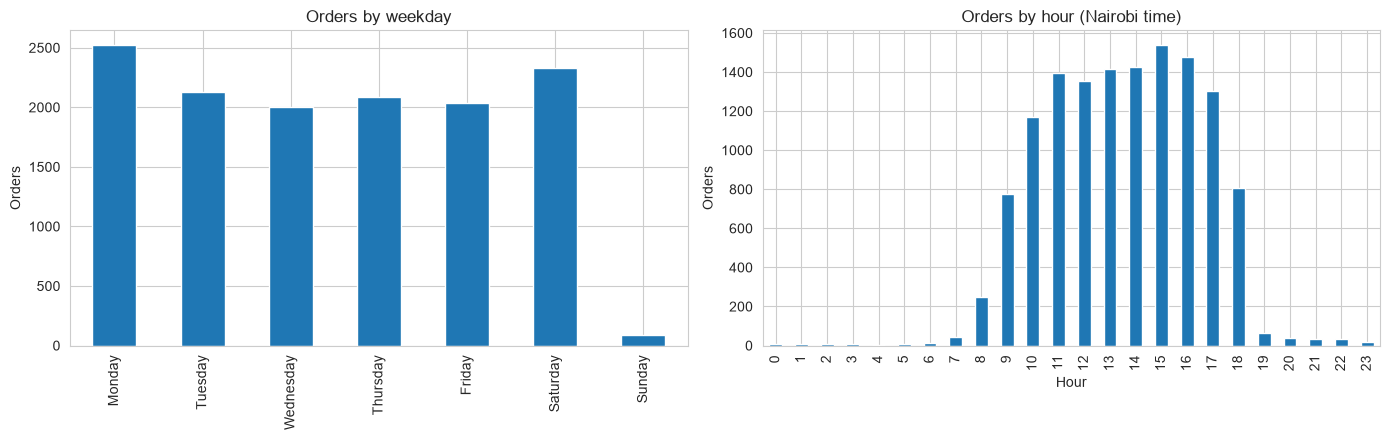

Discount rate (discounts / gross sales): 0.28%
Return lines: 317 | returns value: KES -689,647


,order_name,product,net_quantity,returns,net_sales
5,TS1014,Aptamil 1 First Baby Milk Formula from Birth 800g,-1,-3000.0,-3000.0
65,TS1039,Rider,-1,-700.0,-700.0
153,TS1018,Mamia Ultra Dry Junior Size 5-72 Nappies (11-2...,-1,-2500.0,-2500.0
239,TS1094,NaN,0,3400.0,3400.0
240,TS1094,Aptamil Anti-Reflux,-1,-3400.0,-3400.0


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Orders by weekday (Nairobi time)
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wk = items.drop_duplicates("order_name")["weekday"].value_counts().reindex(days)
wk.plot(kind="bar", ax=axes[0]); axes[0].set(title="Orders by weekday", xlabel="", ylabel="Orders")

# Orders by hour of day
items.drop_duplicates("order_name")["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set(title="Orders by hour (Nairobi time)", xlabel="Hour", ylabel="Orders")
plt.tight_layout(); plt.show()

# Discounts and returns, using product lines of both sale types
all_prod = eda[eda["transaction_type"] == "product"]
print(f"Discount rate (discounts / gross sales): {all_prod['discounts'].abs().sum() / all_prod['gross_sales'].sum():.2%}")
ret = eda[eda["sale_type"] == "return"]
print(f"Return lines: {len(ret):,} | returns value: KES {ret['net_sales'].sum():,.0f}")
display(ret[["order_name", "product", "net_quantity", "returns", "net_sales"]].head())

#### Key EDA findings

- **Trend:** *(growth pattern, any dips or spikes)*
- **Seasonality:** *(repeating months, or too little history to tell)*
- **Channels and categories:** *(which dominate, how much is uncategorized)*
- **Data issues to fix in Phase 3:** *(rider charges, duplicate names, missing categories, outliers, returns)*
- **Basket feasibility:** *(share of multi-product orders, typical basket size)*